# Stock reorder dashboard: the numbers

Every number in the README and on the project card comes from this notebook. It reads the warehouse
the pipeline builds (`docker compose up -d`, then `python pipeline.py` or the Airflow DAG), so start
those first. The rules themselves live once, in `sql/03_rules.sql`; this notebook only measures them.

**What is measured, fixed before the first run:**

| Number | Definition |
|---|---|
| Sales rows | rows in the `sales` table: one per day, store and item |
| Stock-out | the first day an item's shelf closes empty (`on_hand = 0`, the day before it was not) |
| Warning days | days between the first reorder flag in the 7 days before a stock-out and the stock-out |
| Flagged in time | a stock-out with at least 5 days of warning. The flag is raised at closing, the 7am email goes out the next morning and the supplier delivers 4 days after the order, before that day's sales: a flag at Sunday's close becomes a Monday order and a Friday-morning delivery, too late for a shelf that empties on Thursday |
| Best sellers | the 10 items with the most units sold, all stores together |
| Slow stock | stock covering more than 30 days of sales (`status = 'Overstock'`), on the last day, with the 2017 month-end range beside it |

One correction, made after the first run: "in time" was first set at 4 days of warning, which counted
4,047 of 4,052 stock-outs. It ignored the night between the flag and the morning order, so it is 5 days.

The stock history is generated by replaying the stores' current habit (`data/make_data.py`): count
every Monday, top every item up to the same shelf level, delivery 4 days later. The rule never placed
those orders; the backtest asks whether it would have seen each stock-out coming.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import psycopg

LEAD_DAYS, WINDOW = 4, 7
IN_TIME = LEAD_DAYS + 1  # flag at closing, order next morning, delivery 4 days later
NAVY, AMBER, GREY = "#0E1630", "#F59E0B", "#94A3B8"
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

conn = psycopg.connect("host=localhost port=5447 dbname=stock user=stock password=stock")

def query(sql):
    cur = conn.execute(sql)
    return pd.DataFrame(cur.fetchall(), columns=[c.name for c in cur.description])

## 1. The data: how many sales rows

In [2]:
sales_rows = query("SELECT count(*) AS n FROM sales").n[0]
print(f"{sales_rows:,} sales rows")
query("SELECT min(date) AS first_day, max(date) AS last_day, count(DISTINCT store) AS stores, count(DISTINCT item) AS items FROM sales")

913,000 sales rows


,first_day,last_day,stores,items
0,2013-01-01,2017-12-31,10,50


## 2. The backtest: did the rule see each stock-out coming?

For every store and item, walk through the days in order. A stock-out starts on a day the shelf
closes empty after a day it did not. Then look back up to 7 days: the earliest day the item was on
the reorder list gives the warning days.

In [3]:
rule = query("""SELECT date, store, item, on_hand, order_qty > 0 AS flagged, status, stock_value, days_of_cover
                FROM stock_rule ORDER BY store, item, date""")
rule["date"] = pd.to_datetime(rule["date"])
rule[["stock_value", "days_of_cover"]] = rule[["stock_value", "days_of_cover"]].astype(float)
by_item = rule.groupby(["store", "item"])

empty = rule["on_hand"].eq(0)
rule["stockout"] = empty & ~by_item["on_hand"].shift(1).eq(0)

# warning days = the largest k (1..7) for which the item was flagged k days before
rule["warning_days"] = 0
for k in range(1, WINDOW + 1):
    flagged_k_days_before = by_item["flagged"].shift(k, fill_value=False).astype(bool)
    rule.loc[flagged_k_days_before, "warning_days"] = k

stockouts = rule[rule["stockout"]].copy()
stockouts["in_time"] = stockouts["warning_days"] >= IN_TIME
total, flagged = len(stockouts), int(stockouts["warning_days"].gt(0).sum())
in_time = int(stockouts["in_time"].sum())
print(f"{total:,} stock-outs: a flag came before {flagged:,} of them, "
      f"{in_time:,} ({in_time / total:.0%}) early enough to order in time")
stockouts["warning_days"].value_counts().sort_index().rename("stock-outs").to_frame().T

4,052 stock-outs: a flag came before 4,052 of them, 1,643 (41%) early enough to order in time


warning_days,3,4,5,6
stock-outs,5,2404,1627,16


## 3. Best sellers: how much warning before they run out

In [4]:
units = query("SELECT item, sum(units_sold) AS units FROM sales GROUP BY item ORDER BY units DESC")
best_sellers = units.item.head(10).tolist()
best = stockouts[stockouts["item"].isin(best_sellers)]
best_warning = best["warning_days"].median()
print(f"Best sellers {best_sellers}: {len(best):,} of the {total:,} stock-outs, "
      f"median warning {best_warning:.0f} days, {best['in_time'].mean():.0%} flagged in time")

Best sellers [15, 28, 13, 18, 25, 38, 22, 45, 36, 8]: 3,919 of the 4,052 stock-outs, median warning 4 days, 41% flagged in time


## 4. Slow stock: how much stock value sits in items with more than 30 days of cover

Measured on the last day, the morning the report and the email describe.

In [5]:
last_day = rule["date"].max()
today = rule[rule["date"] == last_day]
by_status = today.groupby("status")["stock_value"].sum().sort_values(ascending=False)
slow_share = by_status.get("Overstock", 0) / by_status.sum()
print(f"{last_day:%d %b %Y}: {slow_share:.0%} of stock value is in slow stock (more than 30 days of cover)")
by_status.round(0).to_frame("stock value")

31 Dec 2017: 37% of stock value is in slow stock (more than 30 days of cover)


,stock value
status,
OK,4864461.0
Overstock,2842562.0


The last day is a Sunday in the slow season, two days after the Friday delivery, so the same share at
the end of every month of 2017 shows the range.

In [6]:
month_ends = rule[rule["date"].dt.year.eq(2017) & rule["date"].dt.is_month_end]
monthly_slow = month_ends.groupby("date")[["status", "stock_value"]].apply(
    lambda d: d.loc[d["status"].eq("Overstock"), "stock_value"].sum() / d["stock_value"].sum())
print(f"2017 month ends: {monthly_slow.min():.0%} to {monthly_slow.max():.0%}")
monthly_slow.map("{:.0%}".format).rename("slow stock share").to_frame().T

2017 month ends: 8% to 42%


date,2017-01-31,2017-02-28,2017-03-31,2017-04-30,2017-05-31,2017-06-30,2017-07-31,2017-08-31,2017-09-30,2017-10-31,2017-11-30,2017-12-31
slow stock share,42%,36%,29%,19%,18%,14%,8%,18%,18%,21%,20%,37%


## 5. The numbers for the card and the README

In [7]:
results = pd.Series({
    "Sales rows": f"{sales_rows:,}",
    "Stock-outs in the history": f"{total:,}",
    "Stock-outs with a flag before them (1 to 7 days)": f"{flagged:,}",
    "Stock-outs flagged in time (5+ days)": f"{in_time:,} ({in_time / total:.0%})",
    "Median warning before a best seller runs out": f"{best_warning:.0f} days",
    "Stock value in slow stock, last day": f"{slow_share:.0%}",
    "Same, 2017 month ends": f"{monthly_slow.min():.0%} to {monthly_slow.max():.0%}",
})
results.to_frame("result")

,result
Sales rows,"913,000"
Stock-outs in the history,"4,052"
Stock-outs with a flag before them (1 to 7 days),"4,052"
Stock-outs flagged in time (5+ days),"1,643 (41%)"
Median warning before a best seller runs out,4 days
"Stock value in slow stock, last day",37%
"Same, 2017 month ends",8% to 42%


## 6. Charts for the README

**One best seller through a summer:** its stock against the reorder point. The flags are the days
it was on the reorder list; the shaded days its shelf was empty.

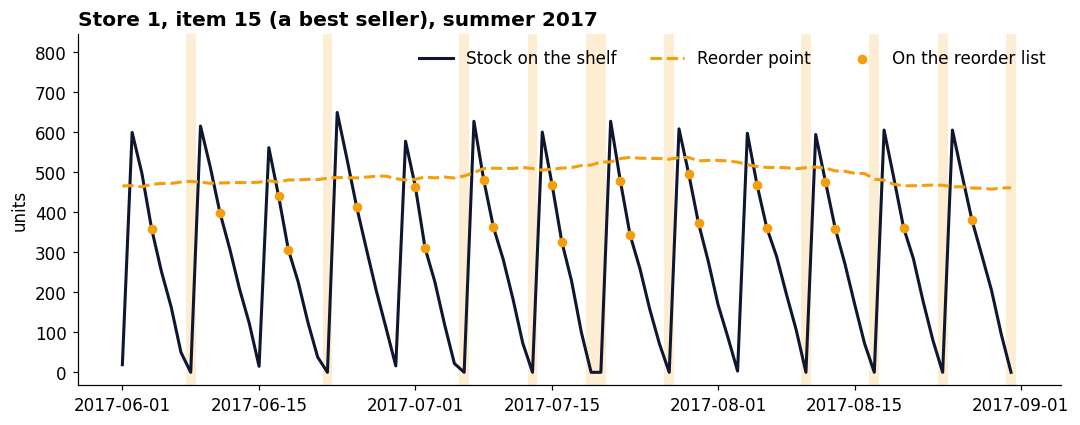

In [8]:
item = best_sellers[0]
one = rule[(rule["store"] == 1) & (rule["item"] == item) & rule["date"].between("2017-06-01", "2017-08-31")]
rop = query(f"""SELECT date, reorder_point FROM stock_rule WHERE store = 1 AND item = {item}
                AND date BETWEEN '2017-06-01' AND '2017-08-31' ORDER BY date""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(one["date"], one["on_hand"], color=NAVY, lw=2, label="Stock on the shelf")
ax.plot(pd.to_datetime(rop["date"]), rop["reorder_point"].astype(float), color=AMBER, lw=2, ls="--", label="Reorder point")
ax.scatter(one.loc[one["flagged"], "date"], one.loc[one["flagged"], "on_hand"], color=AMBER, zorder=3, s=28, label="On the reorder list")
for d in one.loc[one["on_hand"].eq(0), "date"]:
    ax.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12), color=AMBER, alpha=0.18, lw=0)
ax.set_title(f"Store 1, item {item} (a best seller), summer 2017", loc="left", fontweight="bold")
ax.set_ylabel("units")
ax.set_ylim(top=one["on_hand"].max() * 1.3)
ax.legend(frameon=False, loc="upper right", ncol=3)
fig.tight_layout()
fig.savefig("../docs/chart-best-seller-summer.png")

**Stock-outs per month, and how many the rule flagged in time.**

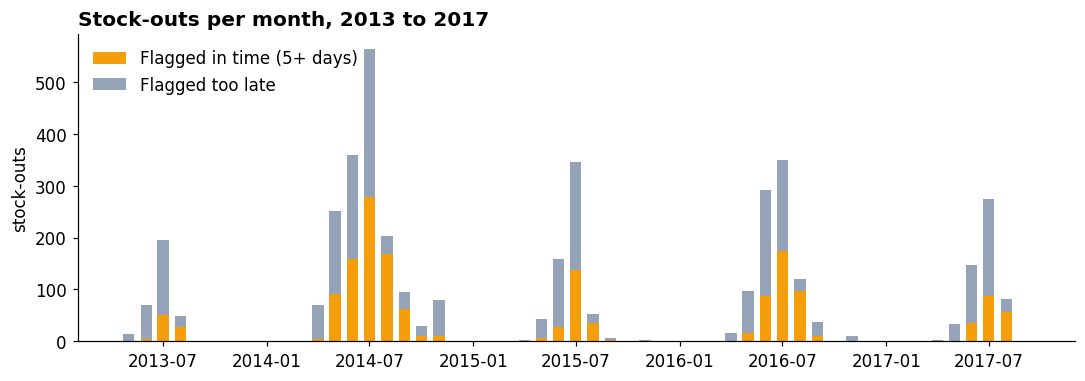

In [9]:
monthly = stockouts.groupby([stockouts["date"].dt.to_period("M"), "in_time"]).size().unstack(fill_value=0)
monthly = monthly.reindex(columns=[True, False], fill_value=0)
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.bar(monthly.index, monthly[True], width=20, color=AMBER, label="Flagged in time (5+ days)")
ax.bar(monthly.index, monthly[False], width=20, bottom=monthly[True], color=GREY, label="Flagged too late")
ax.set_title("Stock-outs per month, 2013 to 2017", loc="left", fontweight="bold")
ax.set_ylabel("stock-outs")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig("../docs/chart-stockouts-per-month.png")

**Where the stock value sits on the last day.**

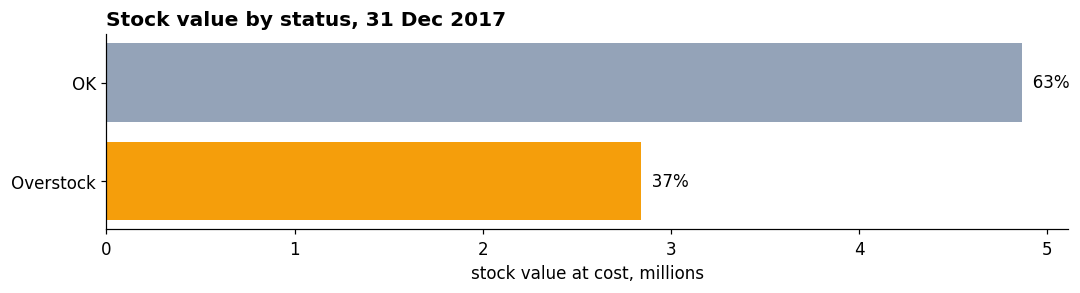

In [10]:
fig, ax = plt.subplots(figsize=(10, 2.8))
colors = [AMBER if s == "Overstock" else GREY for s in by_status.index]
ax.barh(by_status.index[::-1], by_status.values[::-1], color=colors[::-1])
for y, v in enumerate(by_status.values[::-1]):
    ax.text(v, y, f"  {v / by_status.sum():.0%}", va="center")
ax.set_title(f"Stock value by status, {last_day:%d %b %Y}", loc="left", fontweight="bold")
ax.set_xlabel("stock value at cost, millions")
ax.xaxis.set_major_formatter(lambda x, _: f"{x / 1e6:.0f}")
fig.tight_layout()
fig.savefig("../docs/chart-stock-value-by-status.png")

## 7. What the Power BI report must show

`powerbi/06-checks.md` copies these numbers: build the report, pick the same day, and every card must
match.

In [11]:
full = query("SELECT date, store, item, units_sold, on_hand, order_qty, status, stock_value FROM stock_rule")
full["date"] = pd.to_datetime(full["date"])
full["stock_value"] = full["stock_value"].astype(float)

def day_cards(day):
    d = full[full["date"] == day]
    return pd.Series({
        "Items to Reorder": int((d["order_qty"] > 0).sum()),
        "Units to Order": int(d["order_qty"].sum()),
        "Out of Stock Items": int(d["status"].eq("Out of stock").sum()),
        "Stock Value": f"{d['stock_value'].sum():,.0f}",
        "Slow Stock Share": f"{d.loc[d['status'].eq('Overstock'), 'stock_value'].sum() / d['stock_value'].sum():.1%}",
        **{f"Store items: {s}": int(n) for s, n in d["status"].value_counts().items()},
    })

pd.concat({"31 Dec 2017": day_cards("2017-12-31"), "16 Jul 2017": day_cards("2017-07-16")}, axis=1).fillna("0")

,31 Dec 2017,16 Jul 2017
Items to Reorder,0,111
Units to Order,0,98020
Out of Stock Items,0,0
Stock Value,"7,707,022","5,826,826"
Slow Stock Share,36.9%,12.6%
Store items: OK,343,342
Store items: Overstock,157,47
Store items: Reorder,0,111


In [12]:
one_item = full[(full["store"] == 1) & (full["item"] == 15) & full["date"].between("2017-06-01", "2017-08-31")]
pd.Series({
    "Rows (store, item, day)": f"{len(full):,}",
    "Units Sold, all days": f"{full['units_sold'].sum():,}",
    "Empty Shelf Days, all days": f"{full['on_hand'].eq(0).sum():,}",
    "Empty Shelf Days, 2017": f"{full.loc[full['date'].dt.year.eq(2017), 'on_hand'].eq(0).sum():,}",
    "Store 1, item 15, Jun-Aug 2017: Empty Shelf Days": int(one_item["on_hand"].eq(0).sum()),
    "Store 1, item 15, Jun-Aug 2017: Units Sold": f"{one_item['units_sold'].sum():,}",
}).to_frame("must show")

,must show
"Rows (store, item, day)","913,000"
"Units Sold, all days","47,514,528"
"Empty Shelf Days, all days","4,434"
"Empty Shelf Days, 2017",567
"Store 1, item 15, Jun-Aug 2017: Empty Shelf Days",11
"Store 1, item 15, Jun-Aug 2017: Units Sold","9,494"
